## Imports

In [1]:
import numpy as np
import pandas as pd
import torch

## Load data

In [2]:
import os

from google.colab import drive

drive.mount("/content/drive")


DATA_RAW_DIR = "/content/drive/MyDrive/DroneAcharaya/data/raw"
ARTIFACTS_DIR = "/content/drive/MyDrive/DroneAcharaya/ml_artifacts/lstm_rul"

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
import gc

_TELEMETRY_NON_NUMERIC = {"run_id", "engine_state", "engine_id", "mission_id", "data_origin"}
_GT_NON_NUMERIC = {"run_id", "sensor_fault_active_cht_c3", "sensor_fault_active_vibration_rms_x_bearing_proxy"}


def _read_csv_f32(path, non_numeric_cols):
    header_cols = pd.read_csv(path, nrows=0).columns
    dtype_map = {c: "float32" for c in header_cols if c not in non_numeric_cols and c != "t"}
    return pd.read_csv(path, dtype=dtype_map)


telemetry_train_df = _read_csv_f32(f"{DATA_RAW_DIR}/telemetry_train.csv", _TELEMETRY_NON_NUMERIC)
gt_train_df = _read_csv_f32(f"{DATA_RAW_DIR}/groundtruth_train.csv", _GT_NON_NUMERIC)
telemetry_val_df = _read_csv_f32(f"{DATA_RAW_DIR}/telemetry_validation.csv", _TELEMETRY_NON_NUMERIC)
gt_val_df = _read_csv_f32(f"{DATA_RAW_DIR}/groundtruth_validation.csv", _GT_NON_NUMERIC)

telemetry_df = pd.concat([telemetry_train_df, telemetry_val_df], ignore_index=True)
gt_df = pd.concat([gt_train_df, gt_val_df], ignore_index=True)
train_run_ids = set(telemetry_train_df["run_id"].unique())

del telemetry_train_df, gt_train_df, telemetry_val_df, gt_val_df
gc.collect()

print(telemetry_df.shape, gt_df.shape)
print(telemetry_df.columns.tolist())
print(gt_df.columns.tolist())

(3205795, 40) (3205795, 49)
['run_id', 't', 'rpm', 'torque', 'power', 'engine_load', 'cht_c1', 'cht_c2', 'cht_c3', 'cht_c4', 'egt_c1', 'egt_c2', 'egt_c3', 'egt_c4', 'oil_pressure', 'oil_temperature', 'fuel_flow', 'rail_pressure', 'injection_timing', 'boost_pressure', 'map', 'intake_temperature', 'air_mass_flow', 'coolant_temperature', 'vibration_rms_x', 'vibration_order_1x', 'vibration_rms_x_bearing_proxy', 'vibration_order_1x_bearing_proxy', 'battery_voltage', 'battery_current', 'alternator_power', 'altitude', 'ambient_pressure', 'ambient_temperature', 'air_density', 'throttle', 'engine_state', 'engine_id', 'mission_id', 'data_origin']
['run_id', 't', 'rpm_true', 'torque_true', 'cht_c1_true', 'cht_c2_true', 'cht_c3_true', 'cht_c4_true', 'egt_c1_true', 'egt_c2_true', 'egt_c3_true', 'egt_c4_true', 'oil_pressure_true', 'oil_temperature_true', 'fuel_flow_true', 'rail_pressure_true', 'injection_timing_true', 'boost_pressure_true', 'map_true', 'intake_temperature_true', 'air_mass_flow_true'

## Merge

In [4]:
merged_df = pd.merge(
    telemetry_df,
    gt_df,
    on=["run_id", "t"],
    how="inner",
    validate="one_to_one",
)

assert len(merged_df) == len(telemetry_df), "Row count changed after merge — check join key alignment"

del telemetry_df, gt_df
gc.collect()

print(merged_df.shape)

(3205795, 87)


## Column groups

In [5]:
SENSOR_COLUMNS = [
    "rpm",
    "torque",
    "power",
    "engine_load",
    "cht_c1",
    "cht_c2",
    "cht_c3",
    "cht_c4",
    "egt_c1",
    "egt_c2",
    "egt_c3",
    "egt_c4",
    "oil_pressure",
    "oil_temperature",
    "fuel_flow",
    "rail_pressure",
    "injection_timing",
    "boost_pressure",
    "map",
    "intake_temperature",
    "air_mass_flow",
    "coolant_temperature",
    "vibration_rms_x",
    "vibration_order_1x",
    "vibration_rms_x_bearing_proxy",
    "vibration_order_1x_bearing_proxy",
    "battery_voltage",
    "battery_current",
    "alternator_power",
    "altitude",
    "ambient_pressure",
    "ambient_temperature",
    "air_density",
    "throttle",
]

CATEGORICAL_COLUMNS = ["engine_state"]

HEALTH_1_TO_0_COLUMNS = [
    "injector_health_c1",
    "injector_health_c2",
    "injector_health_c3",
    "injector_health_c4",
    "cooling_health",
    "oil_pump_health",
    "bearing_health",
    "fuel_delivery_health",
    "alternator_health",
]
HEALTH_0_TO_1_COLUMNS = [
    "turbo_efficiency_deg",
    "injection_timing_deg",
    "combustion_stability",
    "misfire_rate_c1",
    "misfire_rate_c2",
    "misfire_rate_c3",
    "misfire_rate_c4",
]

SENSOR_FAULT_COLUMNS = [c for c in merged_df.columns if c.startswith("sensor_fault_active_")]
print("Detected sensor-fault columns:", SENSOR_FAULT_COLUMNS)

Detected sensor-fault columns: ['sensor_fault_active_cht_c3', 'sensor_fault_active_vibration_rms_x_bearing_proxy']


## Health sign flip

In [6]:
for col in HEALTH_0_TO_1_COLUMNS:
    merged_df[col] = 1.0 - merged_df[col]

HEALTH_ALL_COLUMNS = HEALTH_1_TO_0_COLUMNS + HEALTH_0_TO_1_COLUMNS
print(f"{len(HEALTH_ALL_COLUMNS)} health columns, all now 1.0=healthy -> 0.0=failed")

merged_df[HEALTH_ALL_COLUMNS].describe().T[["min", "max"]]

16 health columns, all now 1.0=healthy -> 0.0=failed


,min,max
injector_health_c1,0.4,1.0
injector_health_c2,0.4,1.0
injector_health_c3,0.4,1.0
injector_health_c4,0.4,1.0
cooling_health,0.5,1.0
oil_pump_health,0.5,1.0
bearing_health,0.5,1.0
fuel_delivery_health,0.4,1.0
alternator_health,0.5,1.0
turbo_efficiency_deg,0.3,1.0


## Failure thresholds

In [7]:
FAILURE_THRESHOLDS = {
    "injector_health_c1": 0.6,
    "injector_health_c2": 0.6,
    "injector_health_c3": 0.6,
    "injector_health_c4": 0.6,
    "oil_pump_health": 0.5,
    "cooling_health": 0.5,
    "bearing_health": 0.5,
    "fuel_delivery_health": 0.6,
    "alternator_health": 0.5,
    "turbo_efficiency_deg": 0.3,
    "injection_timing_deg": 0.4,
    "combustion_stability": 0.5,
    "misfire_rate_c1": 0.9,
    "misfire_rate_c2": 0.9,
    "misfire_rate_c3": 0.9,
    "misfire_rate_c4": 0.9,
}

missing = set(HEALTH_ALL_COLUMNS) - set(FAILURE_THRESHOLDS)
assert not missing, f"Missing thresholds for: {missing}"

## RUL deviation

In [8]:
def compute_rul_for_run(run_df: pd.DataFrame) -> pd.Series:
    """
    For each timestep, RUL = time until the FIRST future crossing of any health
    parameter below its failure threshold. If a parameter never crosses within
    the run, it does not contribute (treated as right-censored / no failure event
    for that parameter in this run).
    """
    run_df = run_df.sort_values("t").reset_index(drop=True)
    t = run_df["t"].values
    n = len(run_df)
    rul = np.full(n, np.nan)

    first_failure_times = []
    for col, thresh in FAILURE_THRESHOLDS.items():
        below = run_df[col].values <= thresh
        idx = np.argmax(below) if below.any() else -1
        if idx > 0 or (idx == 0 and below[0]):
            first_failure_times.append(t[idx])

    if len(first_failure_times) == 0:
        end_time = t[-1]
        rul = end_time - t
    else:
        nearest_failure_t = min(first_failure_times)
        rul = np.clip(nearest_failure_t - t, a_min=0, a_max=None)

    return pd.Series(rul, index=run_df.index)


rul_parts = []
for run_id, run_df in merged_df.groupby("run_id", sort=False):
    rul_series = compute_rul_for_run(run_df)
    rul_series.index = run_df.index
    rul_parts.append(rul_series)

merged_df["rul"] = pd.concat(rul_parts).sort_index()
merged_df[["run_id", "t", "rul"]].head(10)

,run_id,t,rul
0,UNIT-alternatordegradation-0100_M001,0,1635
1,UNIT-alternatordegradation-0100_M001,1,1634
2,UNIT-alternatordegradation-0100_M001,2,1633
3,UNIT-alternatordegradation-0100_M001,3,1632
4,UNIT-alternatordegradation-0100_M001,4,1631
5,UNIT-alternatordegradation-0100_M001,5,1630
6,UNIT-alternatordegradation-0100_M001,6,1629
7,UNIT-alternatordegradation-0100_M001,7,1628
8,UNIT-alternatordegradation-0100_M001,8,1627
9,UNIT-alternatordegradation-0100_M001,9,1626


## Sensor fault class mapping

In [9]:
SENSOR_FAULT_CLASSES = ["NONE", "BIAS", "DRIFT", "NOISE", "STUCK", "DROPOUT"]
sensor_fault_class_map = {c: i for i, c in enumerate(SENSOR_FAULT_CLASSES)}

for col in SENSOR_FAULT_COLUMNS:
    merged_df[col] = merged_df[col].map(sensor_fault_class_map)

merged_df[SENSOR_FAULT_COLUMNS].head()

,sensor_fault_active_cht_c3,sensor_fault_active_vibration_rms_x_bearing_proxy
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## Train + val split + scaling

In [10]:
import joblib
from sklearn.preprocessing import StandardScaler

train_mask = merged_df["run_id"].isin(train_run_ids)

NAN_PRONE_SENSOR_COLUMNS = ["vibration_rms_x", "vibration_order_1x", "vibration_rms_x_bearing_proxy"]
MISSING_FLAG_COLUMNS = [f"{col}_missing" for col in NAN_PRONE_SENSOR_COLUMNS]

for col, flag_col in zip(NAN_PRONE_SENSOR_COLUMNS, MISSING_FLAG_COLUMNS):
    merged_df[flag_col] = merged_df[col].isna().astype(np.float32)

scaler = StandardScaler()
scaler.fit(merged_df.loc[train_mask, SENSOR_COLUMNS])
joblib.dump(scaler, f"{ARTIFACTS_DIR}/scaler.joblib")
merged_df[SENSOR_COLUMNS] = scaler.transform(merged_df[SENSOR_COLUMNS])

merged_df[NAN_PRONE_SENSOR_COLUMNS] = merged_df[NAN_PRONE_SENSOR_COLUMNS].fillna(0.0)

assert not merged_df[SENSOR_COLUMNS].isna().any().any(), "NaNs remain in SENSOR_COLUMNS after fill"

sensor_fault_class_weights = {}
for col in SENSOR_FAULT_COLUMNS:
    counts = merged_df.loc[train_mask, col].value_counts().reindex(range(len(SENSOR_FAULT_CLASSES)), fill_value=0)
    freq = counts / counts.sum()
    weight = 1.0 / freq.replace(0, np.nan)
    weight = (weight / weight.sum(skipna=True)).fillna(0.0)
    sensor_fault_class_weights[col] = torch.tensor(weight.values, dtype=torch.float32)
    print(f"{col} class weights:", dict(zip(SENSOR_FAULT_CLASSES, weight.round(4))))

sensor_fault_active_cht_c3 class weights: {'NONE': 0.0064, 'BIAS': 0.2592, 'DRIFT': 0.1412, 'NOISE': 0.2607, 'STUCK': 0.3325, 'DROPOUT': 0.0}
sensor_fault_active_vibration_rms_x_bearing_proxy class weights: {'NONE': 0.0002, 'BIAS': 0.0, 'DRIFT': 0.0, 'NOISE': 0.0, 'STUCK': 0.0, 'DROPOUT': 0.9998}


## Encoder

In [11]:
import joblib
from sklearn.preprocessing import OneHotEncoder

ENGINE_STATE_CATEGORIES = [
    "OFF",
    "STARTING",
    "IDLE",
    "TAKEOFF",
    "CLIMB",
    "CRUISE",
    "HIGH_ALTITUDE_CRUISE",
    "LOITER",
    "THROTTLE_TRANSIENT",
    "DESCENT",
    "SHUTDOWN",
    "FAULT",
]

engine_state_encoder = OneHotEncoder(
    categories=[ENGINE_STATE_CATEGORIES],
    handle_unknown="ignore",
    sparse_output=False,
    dtype=np.float32,
)

engine_state_encoder.fit(merged_df.loc[train_mask, ["engine_state"]])

engine_state_encoded = engine_state_encoder.transform(merged_df[["engine_state"]])
engine_state_col_names = engine_state_encoder.get_feature_names_out(["engine_state"]).tolist()

for i, col_name in enumerate(engine_state_col_names):
    merged_df[col_name] = engine_state_encoded[:, i]
del engine_state_encoded
gc.collect()

joblib.dump(engine_state_encoder, f"{ARTIFACTS_DIR}/engine_state_encoder.joblib")

print("engine_state columns:", engine_state_col_names)

engine_state columns: ['engine_state_OFF', 'engine_state_STARTING', 'engine_state_IDLE', 'engine_state_TAKEOFF', 'engine_state_CLIMB', 'engine_state_CRUISE', 'engine_state_HIGH_ALTITUDE_CRUISE', 'engine_state_LOITER', 'engine_state_THROTTLE_TRANSIENT', 'engine_state_DESCENT', 'engine_state_SHUTDOWN', 'engine_state_FAULT']


## FEATURE_COLUMNS

In [12]:
FEATURE_COLUMNS = SENSOR_COLUMNS + MISSING_FLAG_COLUMNS + engine_state_col_names
TARGET_HEALTH_COLUMNS = HEALTH_ALL_COLUMNS
TARGET_RUL_COLUMN = "rul"
TARGET_SENSOR_FAULT_COLUMNS = SENSOR_FAULT_COLUMNS

print(f"{len(FEATURE_COLUMNS)} input features")
print(f"{len(TARGET_HEALTH_COLUMNS)} health targets")
print(f"{len(TARGET_SENSOR_FAULT_COLUMNS)} sensor-fault targets")

49 input features
16 health targets
2 sensor-fault targets


## Build windows

In [13]:
def build_windows(df, feature_cols, health_cols, rul_col, sensor_fault_cols, seq_len=60, stride=1, forecast_horizon=0):
    X_list, y_health_list, y_rul_list, y_sensor_fault_list = [], [], [], []

    for run_id, run_df in df.groupby("run_id", sort=False):
        run_df = run_df.sort_values("t").reset_index(drop=True)
        n = len(run_df)
        if n < seq_len + forecast_horizon:
            continue

        feats = run_df[feature_cols].values
        health = run_df[health_cols].values
        rul = run_df[rul_col].values
        sensor_fault = run_df[sensor_fault_cols].values

        for start in range(0, n - seq_len - forecast_horizon + 1, stride):
            end = start + seq_len
            label_idx = end - 1 + forecast_horizon
            X_list.append(feats[start:end])
            y_health_list.append(health[label_idx])
            y_rul_list.append(rul[label_idx])
            y_sensor_fault_list.append(sensor_fault[label_idx])

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_health_list, dtype=np.float32),
        np.array(y_rul_list, dtype=np.float32),
        np.array(y_sensor_fault_list, dtype=np.int64),
    )


train_df = merged_df[train_mask]
val_df = merged_df[~train_mask]

WINDOW_STRIDE = 10

X_train, y_health_train, y_rul_train, y_sensor_fault_train = build_windows(
    train_df,
    FEATURE_COLUMNS,
    TARGET_HEALTH_COLUMNS,
    TARGET_RUL_COLUMN,
    TARGET_SENSOR_FAULT_COLUMNS,
    seq_len=60,
    stride=WINDOW_STRIDE,
    forecast_horizon=60,
)
X_val, y_health_val, y_rul_val, y_sensor_fault_val = build_windows(
    val_df,
    FEATURE_COLUMNS,
    TARGET_HEALTH_COLUMNS,
    TARGET_RUL_COLUMN,
    TARGET_SENSOR_FAULT_COLUMNS,
    seq_len=60,
    stride=WINDOW_STRIDE,
    forecast_horizon=60,
)

RUL_SCALE_SECONDS = 3600.0
y_rul_train = y_rul_train / RUL_SCALE_SECONDS
y_rul_val = y_rul_val / RUL_SCALE_SECONDS

print("Train:", X_train.shape, y_health_train.shape, y_rul_train.shape, y_sensor_fault_train.shape)
print("Val:  ", X_val.shape, y_health_val.shape, y_rul_val.shape, y_sensor_fault_val.shape)
print(f"y_rul_train range after /{RUL_SCALE_SECONDS:.0f}s: [{y_rul_train.min():.3f}, {y_rul_train.max():.3f}]")

Train: (237881, 60, 49) (237881, 16) (237881,) (237881, 2)
Val:   (65838, 60, 49) (65838, 16) (65838,) (65838, 2)
y_rul_train range after /3600s: [0.000, 1.910]


## Exploratory Data Analysis of Target Variables

Understanding the distribution of target variables is crucial for effective model training. This section will visualize the distributions of RUL, health parameters, and sensor fault classes.

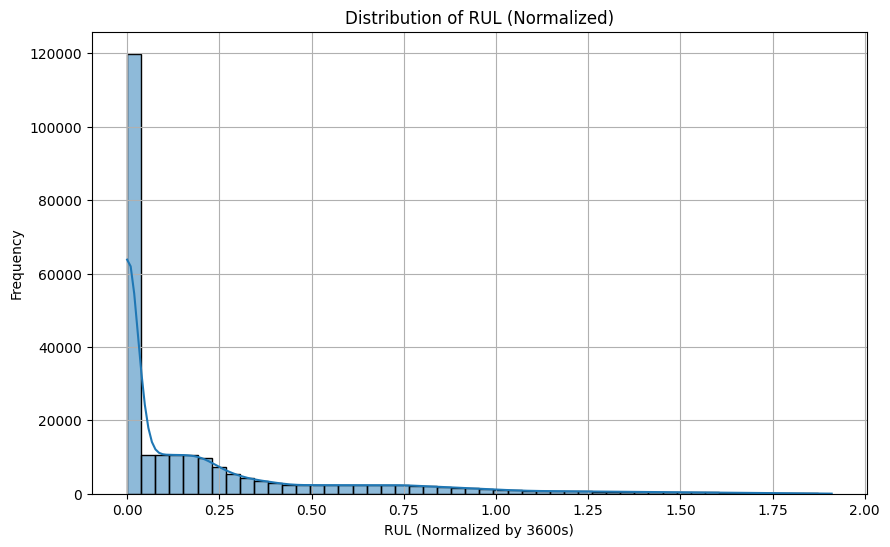

RUL (normalized) statistics:
Mean: 0.2102
Std: 0.3388
Min: 0.0000
Max: 1.9103


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_rul_train, bins=50, kde=True)
plt.title("Distribution of RUL (Normalized)")
plt.xlabel("RUL (Normalized by 3600s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

rul_stats = f"Mean: {y_rul_train.mean():.4f}\nStd: {y_rul_train.std():.4f}\n"
rul_stats += f"Min: {y_rul_train.min():.4f}\nMax: {y_rul_train.max():.4f}"
print(f"RUL (normalized) statistics:\n{rul_stats}")

### Health Parameter Distributions

Visualizing the distribution of each health parameter helps understand their typical values and ranges. Since health values are between 0 and 1 (1.0=healthy -> 0.0=failed), we'll look for parameters that might be skewed or have unusual patterns.

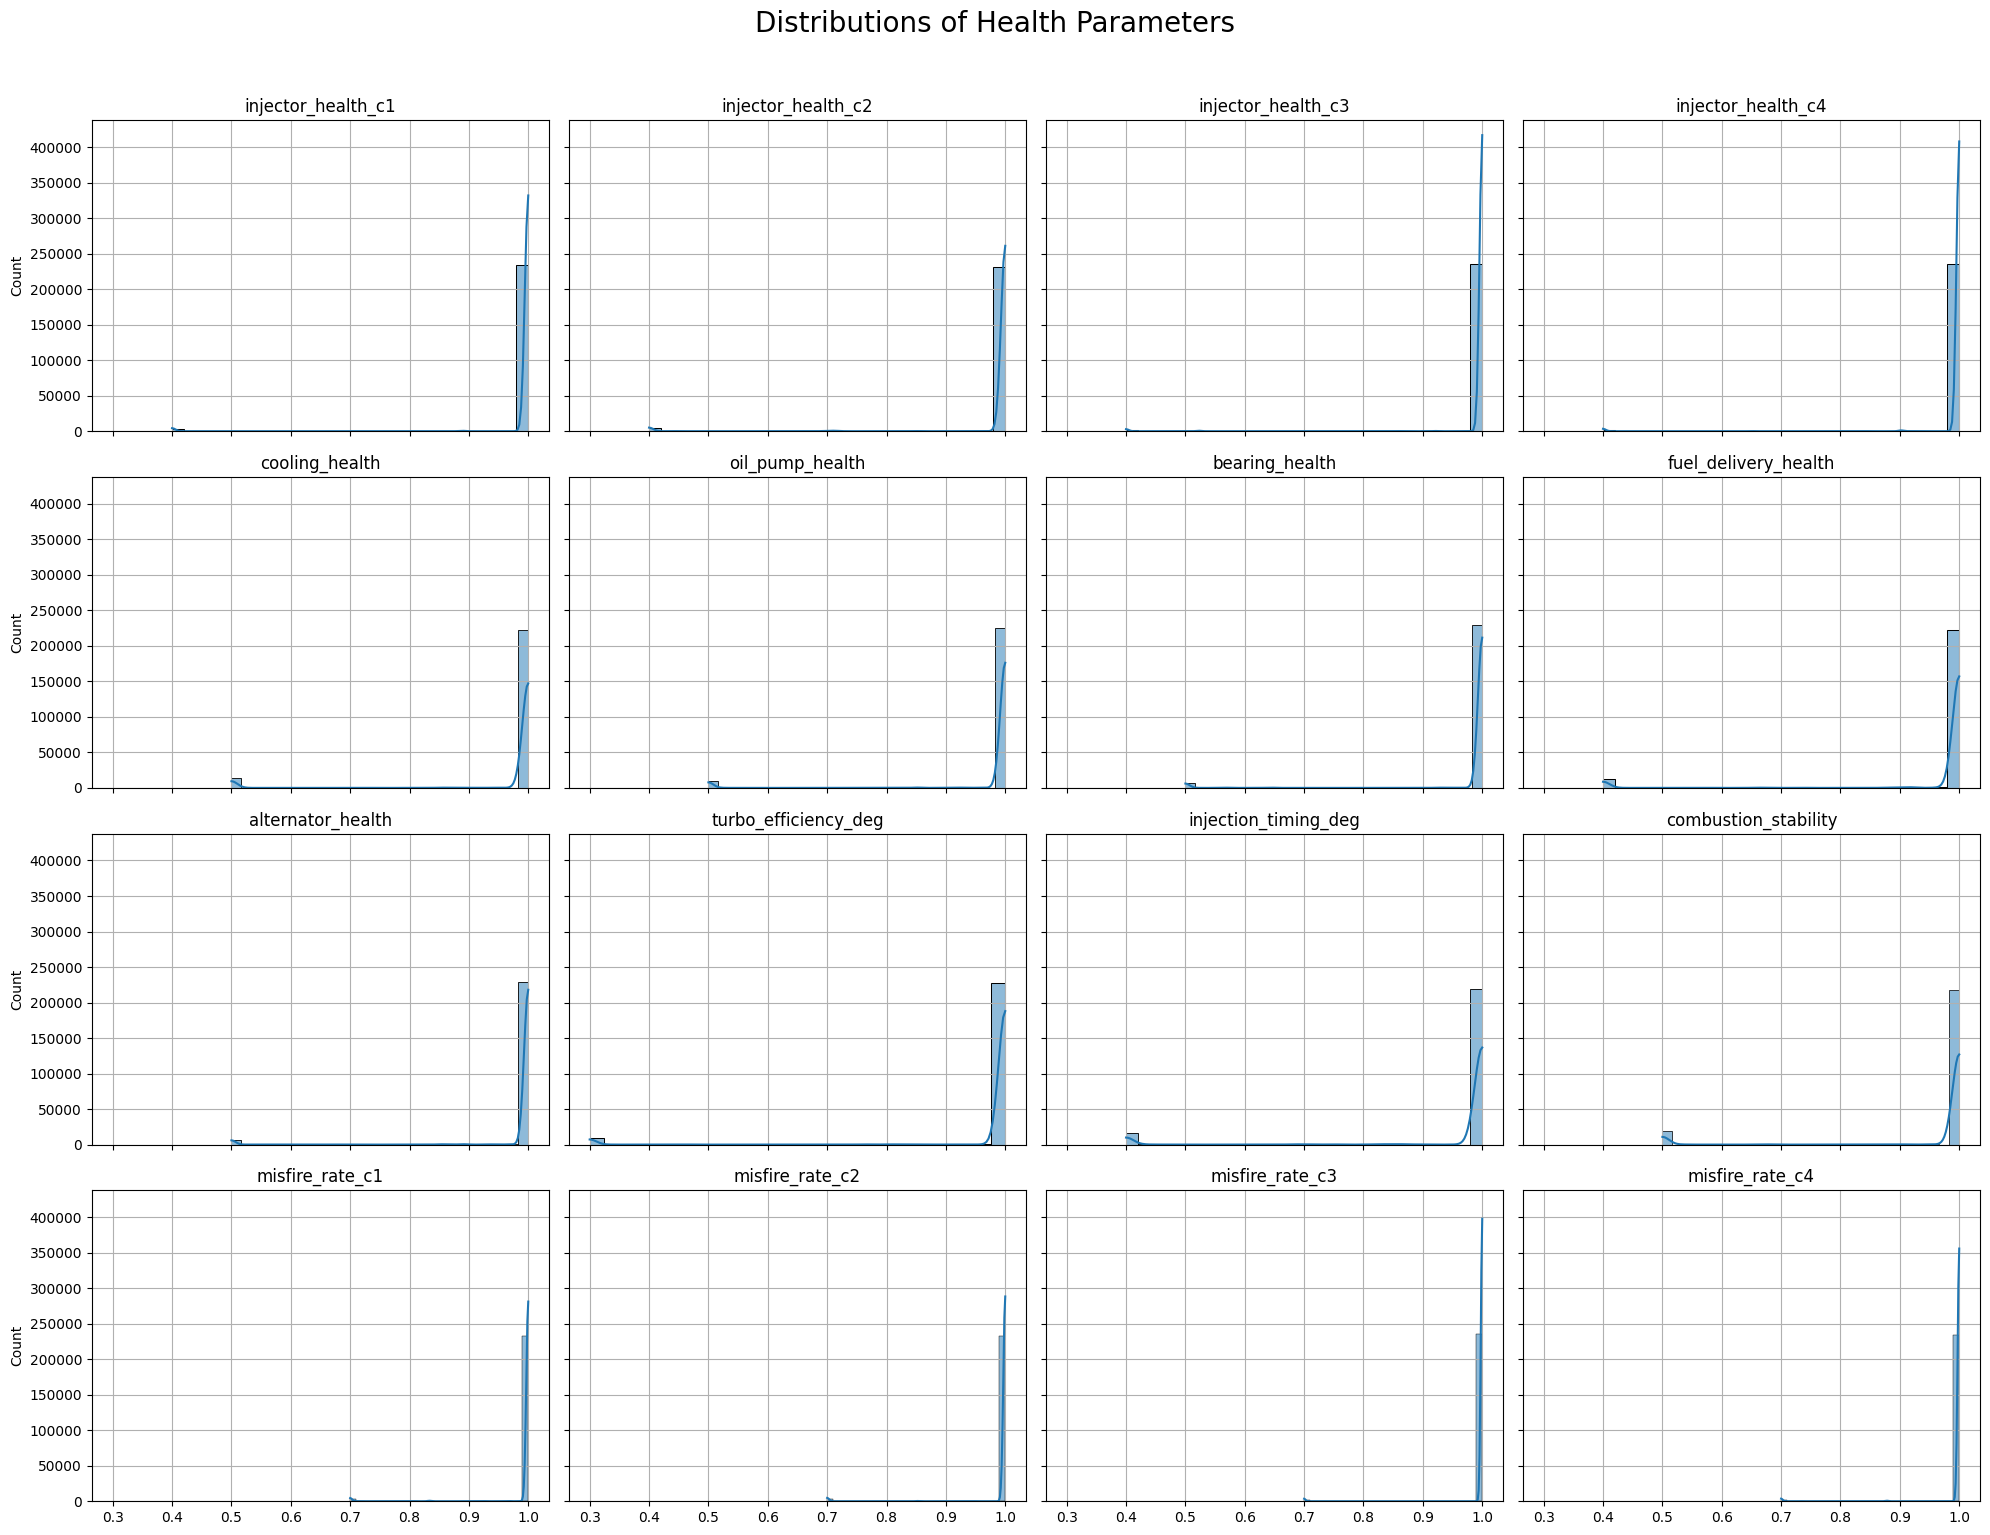

In [15]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, col in enumerate(TARGET_HEALTH_COLUMNS):
    sns.histplot(y_health_train[:, i], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].grid(True)

plt.suptitle("Distributions of Health Parameters", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

### Sensor Fault Class Distributions

Analyzing the distribution of sensor fault classes is crucial, especially for imbalanced datasets, which often necessitate class weighting or other techniques to improve classification performance.

/tmp/ipykernel_910/32511273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_sensor_fault_train[:, i], ax=axes[i], palette='viridis')
/tmp/ipykernel_910/32511273.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels([SENSOR_FAULT_CLASSES[int(j)] for j in sorted(np.unique(y_sensor_fault_train[:, i]))], rotation=45, ha='right')
/tmp/ipykernel_910/32511273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_sensor_fault_train[:, i], ax=axes[i], palette='viridis')
/tmp/ipykernel_910/32511273.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks

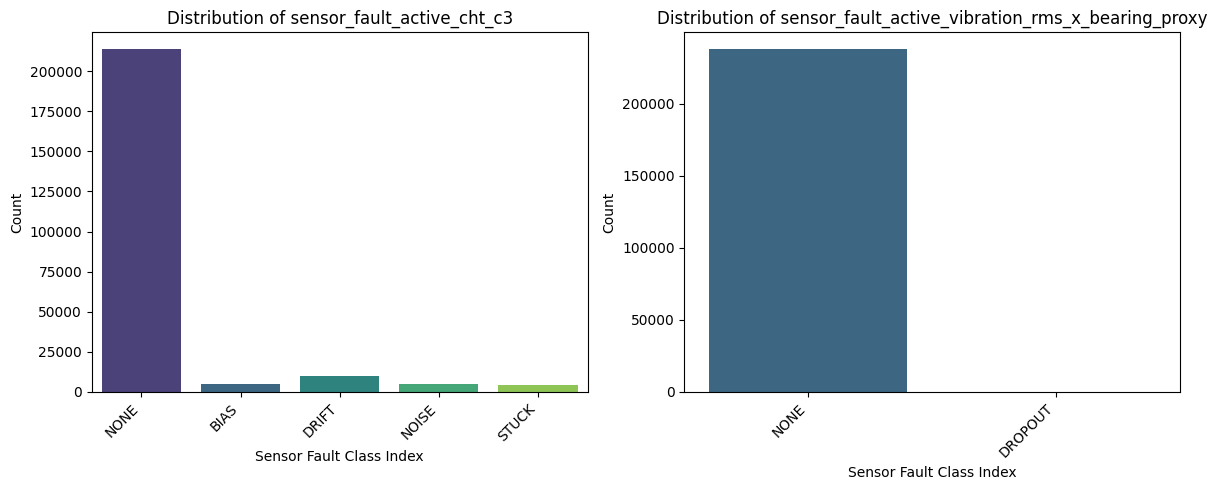


Value counts for sensor_fault_active_cht_c3:
  NONE: 213578 (89.78%)
  BIAS: 5257 (2.21%)
  DRIFT: 9695 (4.08%)
  NOISE: 5238 (2.20%)
  STUCK: 4113 (1.73%)

Value counts for sensor_fault_active_vibration_rms_x_bearing_proxy:
  NONE: 237838 (99.98%)
  DROPOUT: 43 (0.02%)


In [16]:
fig, axes = plt.subplots(nrows=1, ncols=len(TARGET_SENSOR_FAULT_COLUMNS), figsize=(12, 5))

for i, col in enumerate(TARGET_SENSOR_FAULT_COLUMNS):
    sns.countplot(x=y_sensor_fault_train[:, i], ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Sensor Fault Class Index")
    axes[i].set_ylabel("Count")
    fault_classes_present = sorted(np.unique(y_sensor_fault_train[:, i]))
    tick_labels = [SENSOR_FAULT_CLASSES[int(j)] for j in fault_classes_present]
    axes[i].set_xticklabels(tick_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()

for i, col in enumerate(TARGET_SENSOR_FAULT_COLUMNS):
    print(f"\nValue counts for {col}:")
    unique, counts = np.unique(y_sensor_fault_train[:, i], return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  {SENSOR_FAULT_CLASSES[int(u)]}: {c} ({c / len(y_sensor_fault_train):.2%})")

## Sanity checks

In [17]:
assert np.nanmin(y_health_train) >= -1e-3 and np.nanmax(y_health_train) <= 1.0 + 1e-3

assert np.nanmin(y_rul_train) >= 0

assert y_sensor_fault_train.min() >= 0 and y_sensor_fault_train.max() < len(SENSOR_FAULT_CLASSES)

print("All sanity checks passed.")

All sanity checks passed.


## LSTM training

In [18]:
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
class EngineDataset(Dataset):
    def __init__(self, X, y_health, y_rul, y_sensor_fault):
        self.X = torch.from_numpy(X)
        self.y_health = torch.from_numpy(y_health)
        self.y_rul = torch.from_numpy(y_rul)
        self.y_sensor_fault = torch.from_numpy(y_sensor_fault)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y_health[idx], self.y_rul[idx], self.y_sensor_fault[idx]


train_dataset = EngineDataset(X_train, y_health_train, y_rul_train, y_sensor_fault_train)
INPUT_SIZE = X_train.shape[2]
del X_train, y_health_train, y_rul_train, y_sensor_fault_train
gc.collect()

val_dataset = EngineDataset(X_val, y_health_val, y_rul_val, y_sensor_fault_val)
del X_val, y_health_val, y_rul_val, y_sensor_fault_val
gc.collect()

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} windows | Val: {len(val_dataset)} windows")

Train: 237881 windows | Val: 65838 windows


In [28]:
class EngineMultiHeadLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        num_health_params,
        num_sensor_channels,
        num_sensor_fault_classes=6,
        hidden_size=256,
        num_layers=3,
        dropout=0.5,
        bidirectional=False,
    ):
        super().__init__()
        self.num_sensor_channels = num_sensor_channels
        self.num_sensor_fault_classes = num_sensor_fault_classes
        direction_factor = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )

        self.attn_fc = nn.Linear(hidden_size * direction_factor, 1)

        shared_dim = hidden_size * direction_factor
        self.shared_fc = nn.Sequential(
            nn.Linear(shared_dim, shared_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.health_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_health_params),
            nn.Sigmoid(),
        )

        self.rul_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

        self.sensor_fault_head = nn.Sequential(
            nn.Linear(shared_dim // 2, 128),
            nn.ReLU(),
            nn.Linear(128, num_sensor_channels * num_sensor_fault_classes),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        attn_scores = self.attn_fc(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)

        shared = self.shared_fc(context)

        health_pred = self.health_head(shared)
        rul_pred = nn.functional.softplus(self.rul_head(shared)).squeeze(-1)
        sensor_fault_logits = self.sensor_fault_head(shared)
        sensor_fault_logits = sensor_fault_logits.view(-1, self.num_sensor_channels, self.num_sensor_fault_classes)

        return health_pred, rul_pred, sensor_fault_logits, attn_weights

In [29]:
def joint_loss(
    health_pred,
    health_true,
    rul_pred,
    rul_true,
    sensor_fault_logits,
    sensor_fault_true,
    alpha=1.0,
    beta=1.0,
    gamma=0.1,
    class_weights=None,
):
    health_loss = nn.functional.mse_loss(health_pred, health_true)
    rul_loss = nn.functional.mse_loss(rul_pred, rul_true)

    batch, num_channels, num_classes = sensor_fault_logits.shape
    per_channel_losses = []
    for c in range(num_channels):
        weight = class_weights[c].to(sensor_fault_logits.device) if class_weights is not None else None
        per_channel_losses.append(
            nn.functional.cross_entropy(sensor_fault_logits[:, c, :], sensor_fault_true[:, c], weight=weight)
        )
    sensor_fault_loss = torch.stack(per_channel_losses).mean()

    total = alpha * health_loss + beta * rul_loss + gamma * sensor_fault_loss
    return total, health_loss.item(), rul_loss.item(), sensor_fault_loss.item()

In [30]:
def run_epoch(model, loader, optimizer=None, alpha=1.0, beta=1.0, gamma=0.4, class_weights=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    totals = {"loss": 0.0, "health": 0.0, "rul": 0.0, "sensor_fault": 0.0}

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X, y_health, y_rul, y_sensor_fault in loader:
            X = X.to(device)
            y_health = y_health.to(device)
            y_rul = y_rul.to(device)
            y_sensor_fault = y_sensor_fault.to(device)

            if is_train:
                optimizer.zero_grad()

            health_pred, rul_pred, sensor_fault_logits, _ = model(X)
            loss, h_l, r_l, sf_l = joint_loss(
                health_pred,
                y_health,
                rul_pred,
                y_rul,
                sensor_fault_logits,
                y_sensor_fault,
                alpha,
                beta,
                gamma,
                class_weights,
            )

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            totals["loss"] += loss.item()
            totals["health"] += h_l
            totals["rul"] += r_l
            totals["sensor_fault"] += sf_l

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

In [31]:
NUM_HEALTH_PARAMS = len(TARGET_HEALTH_COLUMNS)
NUM_SENSOR_CHANNELS = len(SENSOR_FAULT_COLUMNS)
NUM_SENSOR_FAULT_CLASSES = 6

model = EngineMultiHeadLSTM(
    input_size=INPUT_SIZE,
    num_health_params=NUM_HEALTH_PARAMS,
    num_sensor_channels=NUM_SENSOR_CHANNELS,
    num_sensor_fault_classes=NUM_SENSOR_FAULT_CLASSES,
    hidden_size=256,
    num_layers=3,
    dropout=0.5,
    bidirectional=False,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

print(model)

EngineMultiHeadLSTM(
  (lstm): LSTM(49, 256, num_layers=3, batch_first=True, dropout=0.5)
  (attn_fc): Linear(in_features=256, out_features=1, bias=True)
  (shared_fc): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
  )
  (health_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=16, bias=True)
    (3): Sigmoid()
  )
  (rul_head): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
  (sensor_fault_head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=12, bias=True)
  )
)


Consider tuning the `hidden_size`, `num_layers`, and `dropout` values in the `EngineMultiHeadLSTM` initialization above. These parameters significantly impact model capacity and regularization.

In [32]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

patience = 10
current_patience = 0

The training loop below is modified to incorporate the learning rate scheduler and early stopping. The scheduler will reduce the learning rate if the validation loss doesn't improve for `patience=5` epochs. Early stopping will halt training entirely if the `checkpoint_score` doesn't improve for `patience=10` epochs, effectively preventing further overfitting.

In [33]:
import json

NUM_EPOCHS = 60
best_val_loss = float("inf")
LSTM_CHECKPOINT_PATH = f"{ARTIFACTS_DIR}/lstm_best.pt"

sensor_fault_weight_list = [sensor_fault_class_weights[col] for col in SENSOR_FAULT_COLUMNS]

train_losses = []
val_losses = []
train_health_losses = []
val_health_losses = []
train_rul_losses = []
val_rul_losses = []
train_sf_losses = []
val_sf_losses = []

NEW_GAMMA_LOSS_WEIGHT = 0.1

for epoch in range(NUM_EPOCHS):
    train_metrics = run_epoch(
        model, train_loader, optimizer, class_weights=sensor_fault_weight_list, gamma=NEW_GAMMA_LOSS_WEIGHT
    )
    val_metrics = run_epoch(
        model, val_loader, optimizer=None, class_weights=sensor_fault_weight_list, gamma=NEW_GAMMA_LOSS_WEIGHT
    )

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_health_losses.append(train_metrics["health"])
    val_health_losses.append(val_metrics["health"])
    train_rul_losses.append(train_metrics["rul"])
    val_rul_losses.append(val_metrics["rul"])
    train_sf_losses.append(train_metrics["sensor_fault"])
    val_sf_losses.append(val_metrics["sensor_fault"])

    checkpoint_score = val_metrics["health"] + val_metrics["rul"]

    scheduler.step(checkpoint_score)

    if checkpoint_score < best_val_loss:
        best_val_loss = checkpoint_score
        torch.save(model.state_dict(), LSTM_CHECKPOINT_PATH)
        current_patience = 0
    else:
        current_patience += 1

    print(
        f"Epoch {epoch + 1:2d} | "
        f"train_loss={train_metrics['loss']:.4f} "
        f"(h={train_metrics['health']:.4f}, r={train_metrics['rul']:.4f}, sf={train_metrics['sensor_fault']:.4f}) | "
        f"val_loss={val_metrics['loss']:.4f} "
        f"(h={val_metrics['health']:.4f}, r={val_metrics['rul']:.4f}, sf={val_metrics['sensor_fault']:.4f})"
    )

    if current_patience >= patience:
        print(f"Early stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
        break

print(f"\nBest checkpoint score (health+rul): {best_val_loss:.4f} (checkpoint saved to {LSTM_CHECKPOINT_PATH})")

with open(f"{ARTIFACTS_DIR}/rul_scale_seconds.json", "w") as f:
    json.dump({"rul_scale_seconds": RUL_SCALE_SECONDS}, f)

Epoch  1 | train_loss=0.1418 (h=0.0104, r=0.0721, sf=0.5928) | val_loss=0.0769 (h=0.0128, r=0.0363, sf=0.2787)
Epoch  2 | train_loss=0.0844 (h=0.0089, r=0.0478, sf=0.2774) | val_loss=0.0717 (h=0.0113, r=0.0354, sf=0.2493)
Epoch  3 | train_loss=0.0673 (h=0.0070, r=0.0391, sf=0.2117) | val_loss=0.0718 (h=0.0094, r=0.0419, sf=0.2051)
Epoch  4 | train_loss=0.0525 (h=0.0065, r=0.0342, sf=0.1181) | val_loss=0.0845 (h=0.0085, r=0.0613, sf=0.1457)
Epoch  5 | train_loss=0.0470 (h=0.0059, r=0.0308, sf=0.1028) | val_loss=0.0700 (h=0.0076, r=0.0470, sf=0.1550)
Epoch  6 | train_loss=0.0440 (h=0.0057, r=0.0287, sf=0.0958) | val_loss=0.0845 (h=0.0075, r=0.0610, sf=0.1588)
Epoch  7 | train_loss=0.0416 (h=0.0056, r=0.0268, sf=0.0919) | val_loss=0.0779 (h=0.0075, r=0.0546, sf=0.1582)
Epoch  8 | train_loss=0.0400 (h=0.0055, r=0.0257, sf=0.0870) | val_loss=0.0631 (h=0.0072, r=0.0399, sf=0.1603)
Epoch  9 | train_loss=0.0320 (h=0.0053, r=0.0206, sf=0.0616) | val_loss=0.0709 (h=0.0070, r=0.0481, sf=0.1572)
E

NameError: name 'json' is not defined

In [34]:
with open(f"{ARTIFACTS_DIR}/rul_scale_seconds.json", "w") as f:
    json.dump({"rul_scale_seconds": RUL_SCALE_SECONDS}, f)

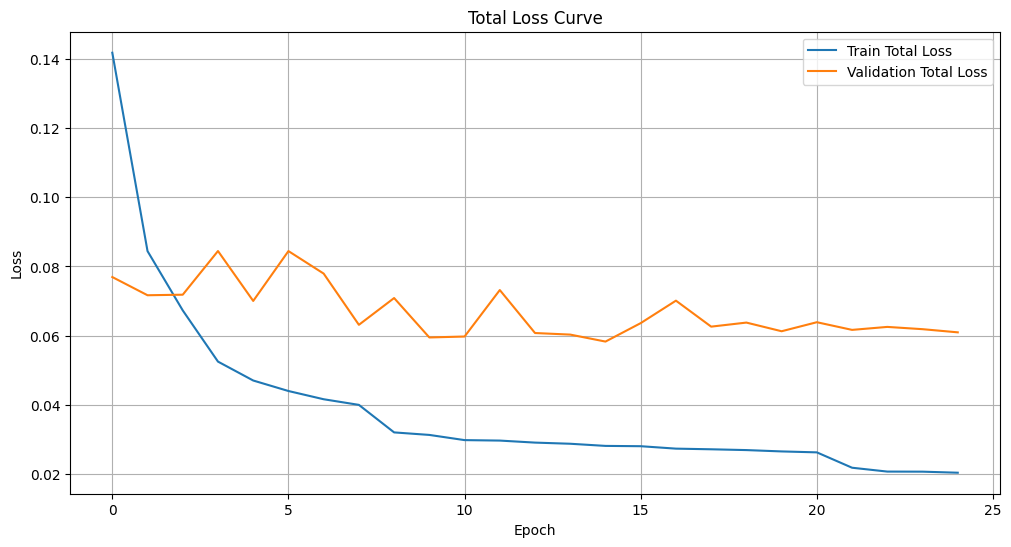

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(train_losses, label="Train Total Loss")
plt.plot(val_losses, label="Validation Total Loss")
plt.title("Total Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

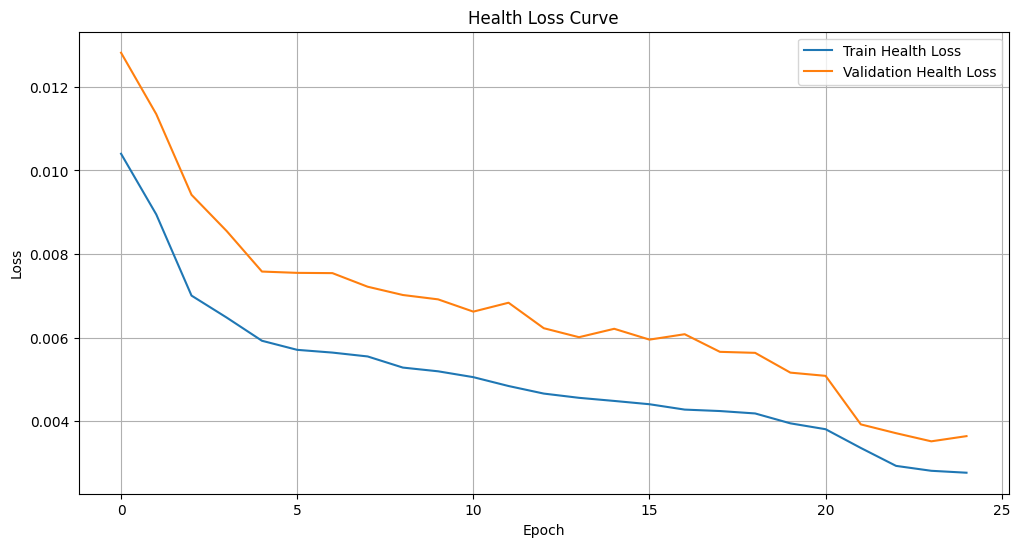

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(train_health_losses, label="Train Health Loss")
plt.plot(val_health_losses, label="Validation Health Loss")
plt.title("Health Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

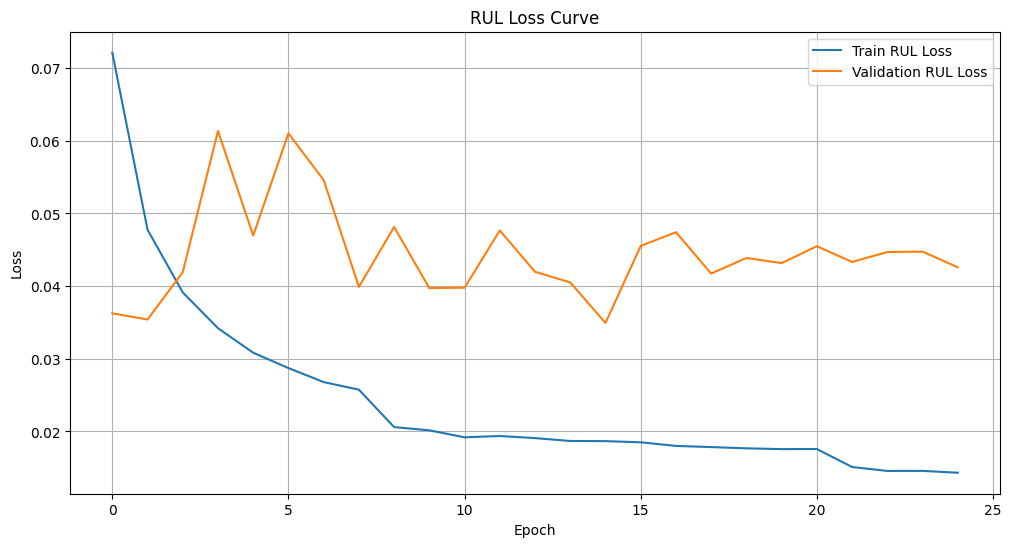

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(train_rul_losses, label="Train RUL Loss")
plt.plot(val_rul_losses, label="Validation RUL Loss")
plt.title("RUL Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

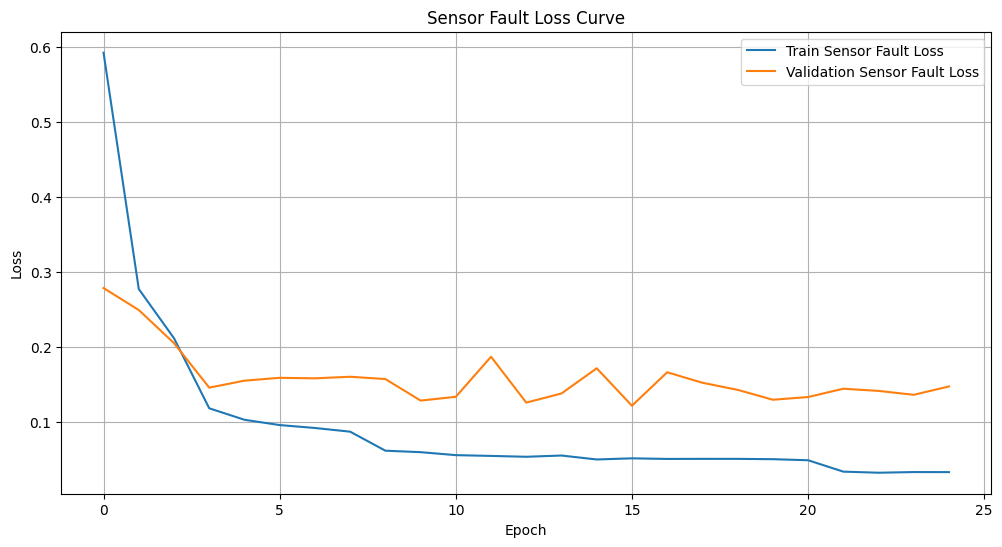

In [38]:
plt.figure(figsize=(12, 6))
plt.plot(train_sf_losses, label="Train Sensor Fault Loss")
plt.plot(val_sf_losses, label="Validation Sensor Fault Loss")
plt.title("Sensor Fault Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Addressing Noisy Validation Loss

Noisy validation loss curves often indicate issues like unstable training or overfitting. Here are strategies to address this:

1.  **Learning Rate Scheduling**: Automatically adjusting the learning rate during training can help stabilize convergence. For example, `ReduceLROnPlateau` reduces the learning rate when validation loss plateaus.
2.  **Early Stopping**: Stop training when validation performance (e.g., loss) stops improving for a specified number of epochs. This prevents overfitting.
3.  **Model Capacity**: Experiment with `hidden_size` and `num_layers` in the `EngineMultiHeadLSTM` class. Too large a model can easily overfit, while too small might underfit.
4.  **Regularization**:
    *   **Dropout**: Adjust the `dropout` rate in the `EngineMultiHeadLSTM` (currently 0.3). Higher dropout can reduce overfitting.
    *   **Weight Decay (L2 Regularization)**: Increase `weight_decay` in the optimizer (currently 1e-5). This penalizes large weights, discouraging complex models.
5.  **Batch Size**: While less common, sometimes tuning the `BATCH_SIZE` can affect gradient stability and convergence.

Below, I will modify the training loop to include a learning rate scheduler and early stopping.

In [39]:
model.load_state_dict(torch.load(LSTM_CHECKPOINT_PATH))
model.eval()

with torch.no_grad():
    X_sample, y_health_sample, y_rul_sample, y_sf_sample = next(iter(val_loader))
    X_sample = X_sample.to(device)

    health_pred, rul_pred, sensor_fault_logits, _ = model(X_sample)
    sensor_fault_pred = sensor_fault_logits.argmax(dim=-1)

    rul_pred_seconds = rul_pred * RUL_SCALE_SECONDS
    y_rul_sample_seconds = y_rul_sample * RUL_SCALE_SECONDS

    print("Predicted RUL, seconds (first 5):", rul_pred_seconds[:5].cpu().numpy())
    print("True RUL, seconds (first 5):     ", y_rul_sample_seconds[:5].numpy())
    print("\nPredicted health[0] (first sample):", health_pred[0].cpu().numpy())
    print("True health[0] (first sample):     ", y_health_sample[0].numpy())

Predicted RUL, seconds (first 5): [690.73236  722.4367   571.1453   139.38147   32.960938]
True RUL, seconds (first 5):      [0. 0. 0. 0. 0.]

Predicted health[0] (first sample): [0.9931704  0.9917528  0.9938916  0.99328905 0.9968124  0.9992223
 0.99367493 0.9827194  0.9934161  0.99678826 0.9982974  0.9887566
 0.9925965  0.99269015 0.9935315  0.9935191 ]
True health[0] (first sample):      [1.  1.  1.  1.  1.  1.  1.  1.  0.5 1.  1.  1.  1.  1.  1.  1. ]


In [40]:
import numpy as np
import torch

rul_tensor = val_dataset.y_rul.to("cpu")

nonzero_idx = torch.where(rul_tensor > 0)[0]
nonzero_frac = len(nonzero_idx) / len(rul_tensor)
print(f"{len(nonzero_idx)} / {len(rul_tensor)} validation windows have RUL > 0 ({nonzero_frac:.1%})")

true_rul_seconds_all = rul_tensor[nonzero_idx] * RUL_SCALE_SECONDS
order = torch.argsort(true_rul_seconds_all)
sorted_idx = nonzero_idx[order]
sorted_rul = true_rul_seconds_all[order]

sample_positions = np.linspace(0, len(sorted_idx) - 1, 10).astype(int)
print("\nSuggested SAMPLE_IDX values (spread across RUL range):")
for pos in sample_positions:
    idx = sorted_idx[pos].item()
    print(f"  SAMPLE_IDX = {idx:6d}   true RUL = {sorted_rul[pos].item():8.1f} s")

23111 / 65838 validation windows have RUL > 0 (35.1%)

Suggested SAMPLE_IDX values (spread across RUL range):
  SAMPLE_IDX =  10457   true RUL =      1.0 s
  SAMPLE_IDX =  58581   true RUL =    159.0 s
  SAMPLE_IDX =  53209   true RUL =    318.0 s
  SAMPLE_IDX =  13883   true RUL =    476.0 s
  SAMPLE_IDX =  21931   true RUL =    635.0 s
  SAMPLE_IDX =  10377   true RUL =    801.0 s
  SAMPLE_IDX =  57451   true RUL =   1053.0 s
  SAMPLE_IDX =  64640   true RUL =   1654.0 s
  SAMPLE_IDX =  53273   true RUL =   2606.0 s
  SAMPLE_IDX =  53862   true RUL =   5503.0 s


In [44]:
import json

import torch

SAMPLE_IDX = 64640

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LSTM_CHECKPOINT_PATH = f"{ARTIFACTS_DIR}/lstm_best.pt"

with open(f"{ARTIFACTS_DIR}/rul_scale_seconds.json", "r") as f:
    rul_scale_data = json.load(f)
RUL_SCALE_SECONDS = rul_scale_data["rul_scale_seconds"]

model = EngineMultiHeadLSTM(
    input_size=INPUT_SIZE,
    num_health_params=NUM_HEALTH_PARAMS,
    num_sensor_channels=NUM_SENSOR_CHANNELS,
    num_sensor_fault_classes=NUM_SENSOR_FAULT_CLASSES,
    hidden_size=256,
    num_layers=3,
    dropout=0.5,
    bidirectional=False,
).to(device)

model.load_state_dict(torch.load(LSTM_CHECKPOINT_PATH))
model.eval()

with torch.no_grad():
    x_single_raw, y_health_single_raw, y_rul_single_raw, y_sf_single_raw = val_dataset[SAMPLE_IDX]

    x_single = x_single_raw.unsqueeze(0).to(device)

    health_pred, rul_pred, sensor_fault_logits, attn_weights = model(x_single)

    rul_pred_seconds = (rul_pred * RUL_SCALE_SECONDS).item()
    true_rul_seconds = float(y_rul_single_raw * RUL_SCALE_SECONDS)

    health_pred_np = health_pred[0].cpu().numpy()
    true_health_np = y_health_single_raw.cpu().numpy()

    sensor_fault_pred_class = sensor_fault_logits[0].argmax(dim=-1).cpu().numpy()
    true_sensor_fault_class = y_sf_single_raw.cpu().numpy()

print(f"=== Sample index {SAMPLE_IDX} ===\n")

rul_error_seconds = rul_pred_seconds - true_rul_seconds
print(
    f"RUL       predicted: {rul_pred_seconds:.2f} s   |   "
    f"true: {true_rul_seconds:.2f} s   |   error: {rul_error_seconds:+.2f} s\n"
)

print("Health (name: pred vs true):")
for name, pred_val, true_val in zip(TARGET_HEALTH_COLUMNS, health_pred_np, true_health_np):
    print(f"  {name:28s} pred={pred_val:.4f}  true={true_val:.4f}  diff={pred_val - true_val:+.4f}")

print("\nSensor fault (channel: predicted class vs true class):")
for i, channel in enumerate(SENSOR_FAULT_COLUMNS):
    pred_cls = SENSOR_FAULT_CLASSES[sensor_fault_pred_class[i]]
    true_cls = SENSOR_FAULT_CLASSES[int(true_sensor_fault_class[i])]
    match = "✓" if pred_cls == true_cls else "✗"
    print(f"  {channel:32s} pred={pred_cls:8s} true={true_cls:8s} {match}")

=== Sample index 64640 ===

RUL       predicted: 2044.89 s   |   true: 1654.00 s   |   error: +390.89 s

Health (name: pred vs true):
  injector_health_c1           pred=0.9915  true=1.0000  diff=-0.0085
  injector_health_c2           pred=0.9868  true=1.0000  diff=-0.0132
  injector_health_c3           pred=0.9921  true=1.0000  diff=-0.0079
  injector_health_c4           pred=0.9911  true=1.0000  diff=-0.0089
  cooling_health               pred=0.9984  true=1.0000  diff=-0.0016
  oil_pump_health              pred=0.9619  true=1.0000  diff=-0.0381
  bearing_health               pred=0.9913  true=1.0000  diff=-0.0087
  fuel_delivery_health         pred=0.9779  true=1.0000  diff=-0.0221
  alternator_health            pred=0.9907  true=1.0000  diff=-0.0093
  turbo_efficiency_deg         pred=0.3957  true=0.3000  diff=+0.0957
  injection_timing_deg         pred=0.9476  true=1.0000  diff=-0.0524
  combustion_stability         pred=0.9999  true=1.0000  diff=-0.0001
  misfire_rate_c1         

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

model = EngineMultiHeadLSTM(
    input_size=INPUT_SIZE,
    num_health_params=NUM_HEALTH_PARAMS,
    num_sensor_channels=NUM_SENSOR_CHANNELS,
    num_sensor_fault_classes=NUM_SENSOR_FAULT_CLASSES,
    hidden_size=256,
    num_layers=3,
    dropout=0.5,
    bidirectional=False,
).to(device)

model.load_state_dict(torch.load(LSTM_CHECKPOINT_PATH))
model.eval()

all_true = [[] for _ in SENSOR_FAULT_COLUMNS]
all_pred = [[] for _ in SENSOR_FAULT_COLUMNS]

with torch.no_grad():
    for X, y_health, y_rul, y_sensor_fault in val_loader:
        X = X.to(device)
        _, _, sensor_fault_logits, _ = model(X)
        pred_classes = sensor_fault_logits.argmax(dim=-1).cpu().numpy()
        true_classes = y_sensor_fault.numpy()

        for c in range(len(SENSOR_FAULT_COLUMNS)):
            all_true[c].extend(true_classes[:, c].tolist())
            all_pred[c].extend(pred_classes[:, c].tolist())

for c, col in enumerate(SENSOR_FAULT_COLUMNS):
    y_true = np.array(all_true[c])
    y_pred = np.array(all_pred[c])
    present_labels = sorted(set(y_true.tolist()) | set(y_pred.tolist()))
    present_names = [SENSOR_FAULT_CLASSES[i] for i in present_labels]

    print(f"\n{'=' * 70}\n{col}\n{'=' * 70}")
    print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=present_labels)
    print("Confusion matrix (rows=true, cols=pred):")
    header = "".join(f"{n:>10s}" for n in present_names)
    print(f"{'':>16s}{header}")
    for i, row_name in enumerate(present_names):
        row = "".join(f"{cm[i, j]:>10d}" for j in range(len(present_names)))
        print(f"{row_name:>16s}{row}")

    none_idx = SENSOR_FAULT_CLASSES.index("NONE")
    true_binary = (y_true != none_idx).astype(int)
    pred_binary = (y_pred != none_idx).astype(int)
    tp = int(((true_binary == 1) & (pred_binary == 1)).sum())
    fn = int(((true_binary == 1) & (pred_binary == 0)).sum())
    fp = int(((true_binary == 0) & (pred_binary == 1)).sum())
    tn = int(((true_binary == 0) & (pred_binary == 0)).sum())
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    print(
        f"\nFault-detected (any non-NONE) view: TP={tp} FN={fn} FP={fp} TN={tn} | "
        f"precision={precision:.3f} recall={recall:.3f}"
    )


sensor_fault_active_cht_c3
              precision    recall  f1-score   support

        NONE       0.99      0.94      0.96     57127
        BIAS       0.90      0.71      0.80      1401
       DRIFT       0.40      0.81      0.53      3221
       NOISE       1.00      0.88      0.93      2059
       STUCK       1.00      0.98      0.99      2030

    accuracy                           0.93     65838
   macro avg       0.86      0.86      0.84     65838
weighted avg       0.96      0.93      0.94     65838

Confusion matrix (rows=true, cols=pred):
                      NONE      BIAS     DRIFT     NOISE     STUCK
            NONE     53588         0      3535         4         0
            BIAS         0       995       406         0         0
           DRIFT       490       107      2620         0         4
           NOISE       243         0         5      1811         0
           STUCK        28         0        19         0      1983

Fault-detected (any non-NONE) view: TP=

In [46]:
DEMO_IDX = 53209

model = EngineMultiHeadLSTM(
    input_size=INPUT_SIZE,
    num_health_params=NUM_HEALTH_PARAMS,
    num_sensor_channels=NUM_SENSOR_CHANNELS,
    num_sensor_fault_classes=NUM_SENSOR_FAULT_CLASSES,
    hidden_size=256,
    num_layers=3,
    dropout=0.5,
    bidirectional=False,
).to(device)

model.load_state_dict(torch.load(LSTM_CHECKPOINT_PATH))
model.eval()

x_demo, y_health_demo, y_rul_demo, y_sf_demo = val_dataset[DEMO_IDX]
x_demo = x_demo.clone()

with torch.no_grad():
    x_input = x_demo.unsqueeze(0).to(device)
    health_pred, rul_pred, sensor_fault_logits, _ = model(x_input)

    rul_pred_seconds = (rul_pred * RUL_SCALE_SECONDS).item()
    true_rul_seconds = float(y_rul_demo * RUL_SCALE_SECONDS)
    sensor_fault_pred_class = sensor_fault_logits[0].argmax(dim=-1).cpu().numpy()

print(f"=== Demo window (index {DEMO_IDX}) ===\n")
print("Forecast target: state 60s AFTER this window's last timestep\n")
print(f"Predicted RUL: {rul_pred_seconds:.1f} s   |   true RUL (unperturbed): {true_rul_seconds:.1f} s")

print("\nHealth (name: pred):")
for name, pred_val in zip(TARGET_HEALTH_COLUMNS, health_pred[0].cpu().numpy()):
    print(f"  {name:28s} pred={pred_val:.4f}")

print("\nSensor fault (channel: predicted class):")
for i, channel in enumerate(SENSOR_FAULT_COLUMNS):
    print(f"  {channel:45s} pred={SENSOR_FAULT_CLASSES[sensor_fault_pred_class[i]]}")

=== Demo window (index 53209) ===

Forecast target: state 60s AFTER this window's last timestep

Predicted RUL: 388.2 s   |   true RUL (unperturbed): 318.0 s

Health (name: pred):
  injector_health_c1           pred=0.9981
  injector_health_c2           pred=0.9977
  injector_health_c3           pred=0.9984
  injector_health_c4           pred=0.9981
  cooling_health               pred=0.9991
  oil_pump_health              pred=0.9995
  bearing_health               pred=0.9991
  fuel_delivery_health         pred=0.9970
  alternator_health            pred=0.9988
  turbo_efficiency_deg         pred=0.9943
  injection_timing_deg         pred=0.9995
  combustion_stability         pred=0.9995
  misfire_rate_c1              pred=0.9979
  misfire_rate_c2              pred=0.9980
  misfire_rate_c3              pred=0.9982
  misfire_rate_c4              pred=0.9982

Sensor fault (channel: predicted class):
  sensor_fault_active_cht_c3                    pred=DRIFT
  sensor_fault_active_vibration